In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
titanic_data = pd.read_csv('/content/titanic_dataset.csv')

In [14]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


3. Make ‘PassengerId’ as the index column

In [15]:
titanic_data.set_index('PassengerId',inplace= True)

In [16]:
titanic_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


4. Check the basic details of the dataset

In [17]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [18]:
titanic_data.shape

(891, 11)

In [19]:
titanic_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
titanic_data.duplicated().sum()

np.int64(0)

In [21]:
titanic_data.dtypes

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


Missing values

In [22]:
## check missing values

titanic_data.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


In [23]:
## remove unwanted colunms name and tiket

In [24]:
titanic_data.drop(["Name", "Ticket"], axis=1, inplace=True)

In [25]:
titanic_data.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
       'Embarked'],
      dtype='object')

In [26]:
## cabin colunm has 75% of missing values, so we drop the colunm
titanic_data=titanic_data.drop('Cabin',axis=1)

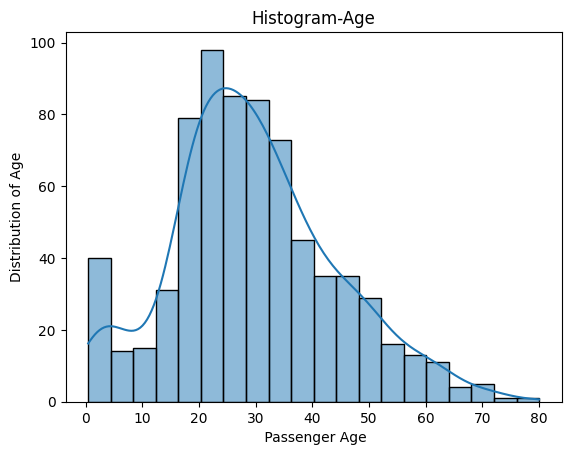

In [27]:
sns.histplot(titanic_data['Age'],kde=True)
plt.xlabel(' Passenger Age')
plt.ylabel('Distribution of Age')
plt.title("Histogram-Age")
plt.show()

In [28]:
##The distribution is right-skewed because the tail extends toward higher ages.
## fill the missing values used median.

In [29]:
titanic_data['Age'] =titanic_data['Age'].fillna(titanic_data['Age'].median())

In [30]:
titanic_data.dropna(subset=['Embarked'],inplace=True)

In [31]:
titanic_data.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0



Outlier

6. Check and handle outliers in at least 3 columns in the dataset

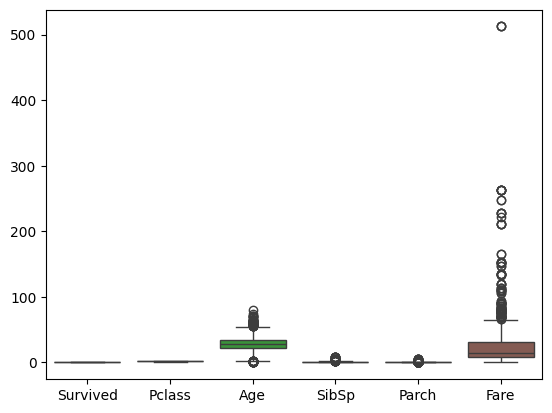

In [32]:
sns.boxplot(titanic_data)
plt.show()

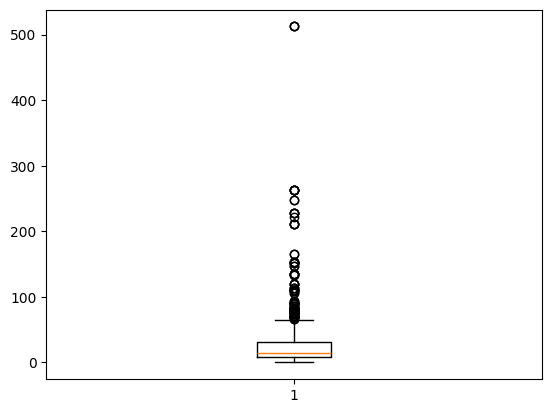

In [33]:
plt.boxplot(titanic_data['Fare'])
plt.show()

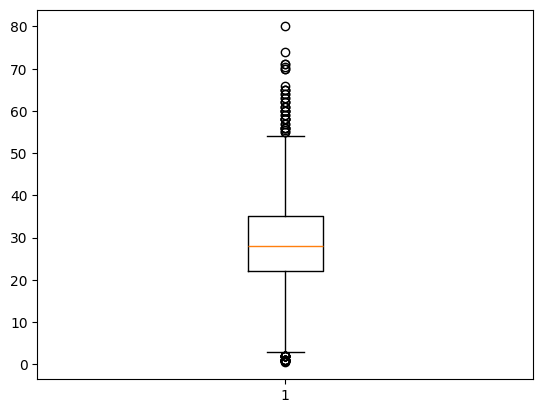

In [34]:
plt.boxplot(titanic_data['Age'])
plt.show()

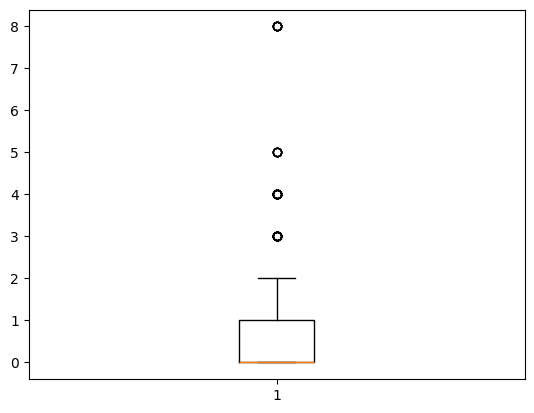

In [35]:
plt.boxplot(titanic_data['SibSp'])
plt.show()

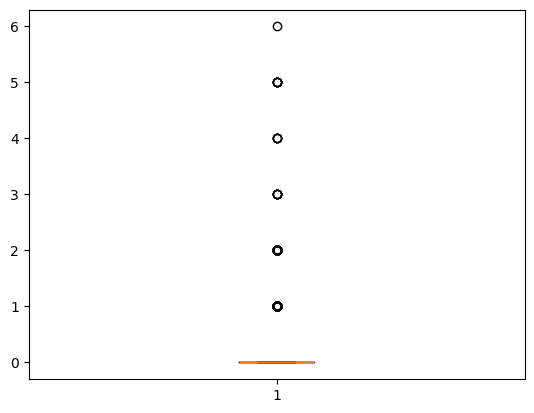

In [36]:
plt.boxplot(titanic_data['Parch'])
plt.show()

In [ ]:
## remove outliers---->Parch and Sibsp,
##clipping outliers age and fare colunms.

In [ ]:
q1 = titanic_data['Parch'].quantile(0.25)
q2 = titanic_data['Parch'].quantile(0.5)
q3 = titanic_data['Parch'].quantile(0.75)


print(f'Q1 = {q1}\nQ2={q2}\nQ3={q3}')

iqr = q3-q1
up_limt =q3+(1.5*iqr)
low_limt =q1- (1.5*iqr)
print(f'IQR ={iqr}\nup_limt ={up_limt}\nlow_limt ={low_limt}')

In [ ]:
titanic_data.nunique().sum()

age colunm cliping

In [37]:
q1 = titanic_data['Age'].quantile(0.25)
q2 = titanic_data['Age'].quantile(0.5)
q3 = titanic_data['Age'].quantile(0.75)


print(f'Q1 = {q1}\nQ2={q2}\nQ3={q3}')

iqr = q3-q1
up_limt =q3+(1.5*iqr)
low_limt =q1- (1.5*iqr)
print(f'IQR ={iqr}\nup_limt ={up_limt}\nlow_limt ={low_limt}')

Q1 = 22.0
Q2=28.0
Q3=35.0
IQR =13.0
up_limt =54.5
low_limt =2.5


In [38]:
titanic_data.loc[titanic_data['Age'] > up_limt, 'Age'] = up_limt
titanic_data.loc[titanic_data['Age'] < low_limt, 'Age'] = low_limt

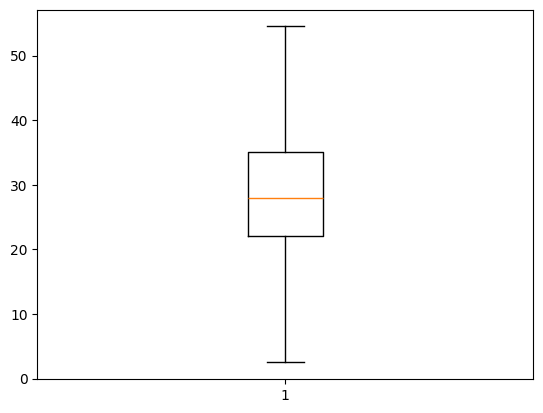

In [39]:
plt.boxplot(titanic_data['Age'])
plt.show()

In [40]:
q1 = titanic_data['Fare'].quantile(0.25)
q2 = titanic_data['Fare'].quantile(0.5)
q3 = titanic_data['Fare'].quantile(0.75)


print(f'Q1 = {q1}\nQ2={q2}\nQ3={q3}')

iqr = q3-q1
up_limt =q3+(1.5*iqr)
low_limt =q1- (1.5*iqr)
print(f'IQR ={iqr}\nup_limt ={up_limt}\nlow_limt ={low_limt}')

Q1 = 7.8958
Q2=14.4542
Q3=31.0
IQR =23.1042
up_limt =65.6563
low_limt =-26.7605


In [41]:
titanic_data.loc[titanic_data['Fare'] > up_limt, 'Fare'] = up_limt
titanic_data.loc[titanic_data['Fare'] < low_limt, 'Fare'] = low_limt

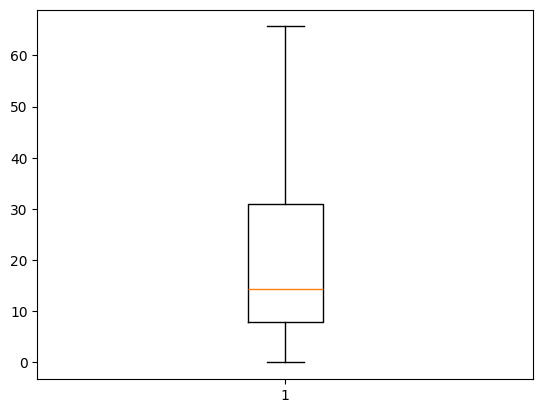

In [42]:
plt.boxplot(titanic_data['Fare'])
plt.show()

In [46]:
#Encoding

In [47]:
titanic_data.dtypes

,0
Survived,int64
Pclass,int64
Sex,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,object


In [48]:
## encoding categorical colunms
## categorical colunms are ---->Sex and Embarked

In [49]:
titanic_data['Sex'].unique()

array(['male', 'female'], dtype=object)

In [50]:
## one-hot encoding
titanic_data = pd.get_dummies(titanic_data,dtype='int',drop_first=True)
titanic_data

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,
1,0,3,22.0,1,0,7.2500,1,0,1
2,1,1,38.0,1,0,65.6563,0,0,0
3,1,3,26.0,0,0,7.9250,0,0,1
4,1,1,35.0,1,0,53.1000,0,0,1
5,0,3,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...
887,0,2,27.0,0,0,13.0000,1,0,1
888,1,1,19.0,0,0,30.0000,0,0,1
889,0,3,28.0,1,2,23.4500,0,0,1


Spliting feature and target colunms

In [51]:
x = titanic_data.drop(['Survived'],axis=1) ##feature and target
y = titanic_data['Survived']

In [52]:
x

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
1,3,22.0,1,0,7.2500,1,0,1
2,1,38.0,1,0,65.6563,0,0,0
3,3,26.0,0,0,7.9250,0,0,1
4,1,35.0,1,0,53.1000,0,0,1
5,3,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...
887,2,27.0,0,0,13.0000,1,0,1
888,1,19.0,0,0,30.0000,0,0,1
889,3,28.0,1,2,23.4500,0,0,1


In [53]:
y

,Survived
PassengerId,
1,0
2,1
3,1
4,1
5,0
...,...
887,0
888,1
889,0


Train Test Spliting

In [55]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2, random_state= 42,stratify=y
)

In [56]:
x_train

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
622,1,42.0,1,0,52.5542,1,0,1
482,2,28.0,0,0,0.0000,1,0,1
528,1,28.0,0,0,65.6563,1,0,1
436,1,14.0,1,2,65.6563,0,0,1
798,3,31.0,0,0,8.6833,0,0,1
...,...,...,...,...,...,...,...,...
360,3,28.0,0,0,7.8792,0,1,0
644,3,28.0,0,0,56.4958,1,0,1
737,3,48.0,1,3,34.3750,0,0,1


In [57]:
y_train

,Survived
PassengerId,
622,1
482,0
528,0
436,1
798,1
...,...
360,1
644,1
737,0


In [58]:
x_test

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
161,3,44.0,0,1,16.1000,1,0,1
127,3,28.0,0,0,7.7500,1,1,0
429,3,28.0,0,0,7.7500,1,1,0
423,3,29.0,0,0,7.8750,1,0,1
566,3,24.0,2,0,24.1500,1,0,1
...,...,...,...,...,...,...,...,...
40,3,14.0,1,0,11.2417,0,0,0
92,3,20.0,0,0,7.8542,1,0,1
884,2,28.0,0,0,10.5000,1,0,1


In [59]:
y_test

,Survived
PassengerId,
161,0
127,0
429,0
423,0
566,0
...,...
40,1
92,0
884,0


Feature Scalling/ Scaling

In [61]:
# creating a copy of my features
x1=x.copy()
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
for i in ['Age','Fare']:
  x1[i] = scaler.fit_transform(x1[[i]])
  x1.describe()


In [62]:
# scaled x_train1 and x_test1
from sklearn.model_selection import train_test_split
x_train1, x_test1, y_train, y_test = train_test_split(x1, y, test_size=0.2, random_state=42, stratify=y)

In [63]:
# non scaled x_train and x_test

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [64]:
x_train.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
622,1,42.0,1,0,52.5542,1,0,1
482,2,28.0,0,0,0.0000,1,0,1
528,1,28.0,0,0,65.6563,1,0,1
436,1,14.0,1,2,65.6563,0,0,1
798,3,31.0,0,0,8.6833,0,0,1


In [65]:
x_train1.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
622,1,0.759615,1,0,0.800444,1,0,1
482,2,0.490385,0,0,0.000000,1,0,1
528,1,0.490385,0,0,1.000000,1,0,1
436,1,0.221154,1,2,1.000000,0,0,1
798,3,0.548077,0,0,0.132254,0,0,1


In [66]:
x_test.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
161,3,44.0,0,1,16.100,1,0,1
127,3,28.0,0,0,7.750,1,1,0
429,3,28.0,0,0,7.750,1,1,0
423,3,29.0,0,0,7.875,1,0,1
566,3,24.0,2,0,24.150,1,0,1


In [67]:
x_test1.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
161,3,0.798077,0,1,0.245216,1,0,1
127,3,0.490385,0,0,0.118039,1,1,0
429,3,0.490385,0,0,0.118039,1,1,0
423,3,0.509615,0,0,0.119943,1,0,1
566,3,0.413462,2,0,0.367825,1,0,1


ML Model

7.Try out all the classification models discussed and find out which one is the best

Classification Models

Logistic regression

In [68]:
from sklearn.linear_model import LogisticRegression

In [69]:
lr_model =LogisticRegression(max_iter=1000)
lr_model.fit(x_train1,y_train)
y_pred_lr_model = lr_model.predict(x_test1)

In [70]:
from sklearn.metrics import confusion_matrix,precision_score,accuracy_score,f1_score,recall_score
print(confusion_matrix(y_test,y_pred_lr_model))
print('Accuracy is: ',accuracy_score(y_test,y_pred_lr_model))
print('Precision is: ',precision_score(y_test,y_pred_lr_model))
print('Recall is: ',recall_score(y_test,y_pred_lr_model))
print('F1 score is: ',f1_score(y_test,y_pred_lr_model))

[[98 12]
 [21 47]]
Accuracy is:  0.8146067415730337
Precision is:  0.7966101694915254
Recall is:  0.6911764705882353
F1 score is:  0.7401574803149606


KNN

In [71]:
#KNN
# Finding the optimum k value
from sklearn.neighbors import KNeighborsClassifier

acc_score =[]
for i in range(3,10):
  knn = KNeighborsClassifier(n_neighbors = i)
  knn.fit(x_train1,y_train)
  y_pred_knn = knn.predict(x_test1)
  acc = accuracy_score(y_test,y_pred_knn)
  acc_score.append(acc)

In [72]:
acc_score

[0.7528089887640449,
 0.7921348314606742,
 0.7640449438202247,
 0.7696629213483146,
 0.7471910112359551,
 0.7584269662921348,
 0.7528089887640449]

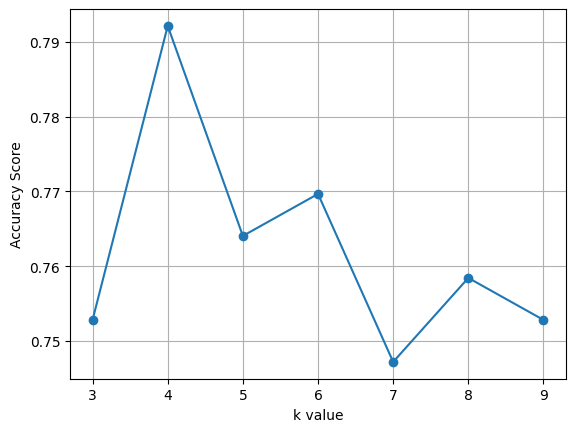

In [73]:
plt.plot(np.arange(3,10),acc_score,'o-')
plt.xlabel('k value')
plt.ylabel('Accuracy Score')
plt.grid()

In [74]:
# optimum k values value is 4 because accuracy is high when k =4
# train the knn model k=4
knn= KNeighborsClassifier(n_neighbors=4)
knn.fit(x_train1,y_train)
y_pred_knn = knn.predict(x_test1)
print(confusion_matrix(y_test,y_pred_knn))
print('Accuracy is : ',accuracy_score(y_test,y_pred_knn))
print('Precision is : ',precision_score(y_test,y_pred_knn))
print('Recall is : ',recall_score(y_test,y_pred_knn))
print('F1 score is : ',f1_score(y_test,y_pred_knn))

[[97 13]
 [24 44]]
Accuracy is :  0.7921348314606742
Precision is :  0.7719298245614035
Recall is :  0.6470588235294118
F1 score is :  0.704


SVM

In [75]:
from sklearn.svm import SVC

In [76]:
#linear kernal
svm_linear =SVC(kernel ='linear')
svm_linear.fit(x_train1,y_train)
y_pred_svm_linear = svm_linear.predict(x_test1)
print(confusion_matrix(y_test,y_pred_svm_linear))
print('Accuracy is : ',accuracy_score(y_test,y_pred_svm_linear))
print('Precision is : ',precision_score(y_test,y_pred_svm_linear))
print('Recall is : ',recall_score(y_test,y_pred_svm_linear))
print('F1 score is : ',f1_score(y_test,y_pred_svm_linear))

[[94 16]
 [25 43]]
Accuracy is :  0.7696629213483146
Precision is :  0.7288135593220338
Recall is :  0.6323529411764706
F1 score is :  0.6771653543307087


Polinomiyal

In [77]:
## polinomial

svm_poly =SVC(kernel ='poly')
svm_poly.fit(x_train1,y_train)
y_pred_svm_poly = svm_poly.predict(x_test1)
print(confusion_matrix(y_test,y_pred_svm_poly))
print('Accuracy is : ',accuracy_score(y_test,y_pred_svm_poly))
print('Precision is : ',precision_score(y_test,y_pred_svm_poly))
print('Recall is : ',recall_score(y_test,y_pred_svm_poly))
print('F1 score is : ',f1_score(y_test,y_pred_svm_poly))

[[98 12]
 [23 45]]
Accuracy is :  0.8033707865168539
Precision is :  0.7894736842105263
Recall is :  0.6617647058823529
F1 score is :  0.72


RBF

In [78]:

##RBF'
svm_rbf =SVC(kernel ='rbf')
svm_rbf.fit(x_train1,y_train)
y_pred_svm_rbf = svm_rbf.predict(x_test1)
print(confusion_matrix(y_test,y_pred_svm_rbf))
print('Accuracy is : ',accuracy_score(y_test,y_pred_svm_rbf))
print('Precision is : ',precision_score(y_test,y_pred_svm_rbf))
print('Recall is : ',recall_score(y_test,y_pred_svm_rbf))
print('F1 score is : ',f1_score(y_test,y_pred_svm_rbf))

[[99 11]
 [27 41]]
Accuracy is :  0.7865168539325843
Precision is :  0.7884615384615384
Recall is :  0.6029411764705882
F1 score is :  0.6833333333333333


Decision Tree

In [79]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion= 'entropy',random_state=42)
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)
print(confusion_matrix(y_test,y_pred_dt))
print('Accuracy is : ',accuracy_score(y_test,y_pred_dt))
print('Precision is : ',precision_score(y_test,y_pred_dt))
print('Recall is : ',recall_score(y_test,y_pred_dt))
print('F1 score is : ',f1_score(y_test,y_pred_dt))

[[90 20]
 [19 49]]
Accuracy is :  0.7808988764044944
Precision is :  0.7101449275362319
Recall is :  0.7205882352941176
F1 score is :  0.7153284671532847


Random Forest

In [ ]:


from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(criterion='entropy',random_state = 42)
rf.fit(x_train,y_train)
y_pred_rf = rf.predict(x_test)
print(confusion_matrix(y_test,y_pred_rf))
print('Accuracy is : ',accuracy_score(y_test,y_pred_rf))
print('Precision is : ',precision_score(y_test,y_pred_rf))
print('Recall is : ',recall_score(y_test,y_pred_rf))
print('F1 score is : ',f1_score(y_test,y_pred_rf))

In [ ]:
## best Accuracy ---->Logistic regression,81